# ARIM情報活用講座：　ケモインフォマテックス応用編　
# 第1回：　分子記述子

## 前提知識・動作環境・版とライセンス

**前提知識**：Python基礎文法。SMILES記法や分子構造の基礎知識があるとより理解が深まりますが、必須ではありません。

**動作環境**：Google Colab、または以下のバージョンで動作確認を行いました。

| ライブラリ | バージョン |
| --- | --- |
| Python | 3.10 |
| rdkit | 2026.03.4 |
| pandas | 2.3.3 |
| numpy | 1.26.4 |
| matplotlib | 3.10.9 |

※ RDKitが実装する記述子の数・種類はバージョンによって変動します。本ノートブックの実行時点（rdkit 2026.03.4）では217種類でしたが、今後のバージョンアップで増減する可能性があります。数値を暗記するのではなく、コードを実行して得られる件数を都度確認してください。

**版とライセンス**：底本は船津 公人、柴山 翔二郎『実践 マテリアルズインフォマティクス　Pythonによる材料設計のための機械学習』（近代科学社、2020）第1章・第5章。データセットの出典は本編内で明記します。本ノートブックはARIMデータポータルセミナー・ワークショップ教材として配布します。


## 本編の目標
分子記述子は、分子の類似性の計算や分類、回帰、クラスタリング、バーチャルスクリーニングなど、さまざまな化学情報処理に使用されます。また機械学習モデルの学習において、分子の特徴ベクトルとして入力されることもあります。本編では、その代表的な記述子としてRDKitに実装されている

1. **Morganフィンガープリント　（ECFP）**
1. **RDKitフィンガープリント　（Daylight Fingerprint）**
1. **RDKit記述子**

の３つの記述子について学びます。

## 分子記述子とは

分子記述子（**molecular descriptors**）とは、分子の構造式や立体構造（2次元・3次元の構造情報）から、数理的・論理的なアルゴリズムによって計算される数値特徴量を指します。単に記述子（**ディスクリプター**）とも称されます。分子骨格の有無、部分構造（**フラグメント**）の数、電気的特性、立体的な形状など、分子の構造的・化学的特徴を、機械学習モデルなどが扱いやすい数値へと変換したものです。

《注意》溶解度・融点・沸点・実験的に測定されたLogPなどの物性値は、分子記述子**そのもの**ではなく、分子記述子を使って**予測する対象（目的変数）**として扱われるのが一般的です（実際、3_Solubility.ipynbでは水溶解度の実測値を目的変数`y`として使い、記述子を説明変数`X`として使っています）。ただし、これらの物性を分子構造から理論的に計算・推定した値（例：計算によるCLogP、Crippenのモル屈折率など）は「理論分子記述子」として広く使われます。分子量についても、実験で測定するというより分子式から一意に計算される値である点に注意してください。

分子記述子は、算出の元となる構造情報の複雑さに応じて、一般に0次元から4次元までに大別されます（Todeschini & Consonniの分類に基づく）。

| 次元| 表現| 具体例 |
| :--| :--| :--|
| 0次元| 分子の組成情報（原子の数・種類のみで、結合情報は使わない） | 分子量、総原子数、元素構成比など |
| 1次元| 特定の部分構造・官能基の存在や個数（分子全体の結合関係までは考慮しない） | 水素結合ドナー／アクセプター数、環の数、官能基別の数など |
| 2次元| 分子の結合関係（トポロジー・グラフ理論）に基づく表現 | 連結性指標（Wiener指数など）、Morgan/ECFPなどの分子フィンガープリント |
| 3次元| 分子の立体構造（3次元座標）に基づく表現 | 幾何学的記述子、3次元極性表面積（3D PSA）、3D-MoRSE、WHIM、GETAWAY記述子など |
| 4次元| 3次元構造に相互作用エネルギーのグリッドや複数コンフォマーの情報を加えた表現 | GRID法、CoMFA法、Volsurfなど |

《注意》RDKitの`Descriptors.TPSA`が計算する極性表面積は、Ertl et al. (2000)が提案した**位相的極性表面積（Topological PSA）**であり、3次元構造を必要とせず2次元の結合情報だけから計算されます（本編の後半で、実際に3次元embeddingを行わずにTPSAを計算していることを確認できます）。上表の「3次元」に分類される極性表面積は、3次元の分子表面から直接計算する古典的な手法を指しており、TPSAとは区別してください。

![図1：分子記述子の次元とその表現](./img/image-2-1.png)

**図1**：分子記述子の次元（0〜4次元）とその表現例


## 分子フィンガープリント

分子記述子のうち、2次元記述子（分子の結合関係・トポロジーに基づく記述子）の代表例として広く使われるのが**分子フィンガープリント**（単に**フィンガープリント**）です。これは、分子内の部分構造や結合パターンを、一定の規則（アルゴリズム）に基づいて固定長の配列（例：256ビットや2048ビット）にエンコードしたものです。人間の指紋のように分子固有の構造的特徴をコンパクトに写し取ることから、この名前が付けられています。

分子フィンガープリントは、主に分子間の構造的な類似性の評価（タニモト係数の算出など）や、機械学習モデルの特徴量として利用されます。数値の表現形式によって、主に次の2種類に大別されます。

(1) **ビットフィンガープリント（Bit Vector）**：
   - 各要素が`0`または`1`のバイナリで表現される固定長のビット列です。
   - アルゴリズムが定義する特定の部分構造（サブストラクチャ）が分子内に「存在するか（1）」「存在しないか（0）」を示すフラグとして機能します。同じ部分構造が複数回出現しても区別されません。
   - データが軽量で計算が高速なため、大規模な化合物データベースからの類似構造検索や、タニモト係数による類似性評価に適しています。本編で扱う`GetMorganGenerator`（Morganフィンガープリント生成器）が返すビットベクトルはこのタイプです。

(2) **カウントフィンガープリント（Count Vector）**：
   - 各要素が`0, 1, 2, 3...`のような整数値（出現回数）で表現されるベクトルです。
   - ビットフィンガープリントと同様の部分構造について、分子内に「何回出現するか」という頻度をエンコードします。同じ部分構造が複数回現れる場合の情報も保持されるため、ビット表現より情報量が多くなります。
   - 3_Solubility.ipynbで扱う`HashedMorgan`クラス（`GetCountFingerprint`を使用）はこのタイプで、物性予測モデルの特徴量として使われています。

《注意》分子量、水素結合ドナー数、融点・沸点（推定値）といった、個々の物理化学的性質を並べたベクトルは、フィンガープリントではなく、次節で扱う**RDKit記述子**に分類されます。フィンガープリントはあくまで「部分構造の有無・頻度」を符号化したものであり、物性値そのものを直接格納するものではない点に注意してください。


## RDKitで用いられる代表的な分子記述子

RDKitで利用できる代表的な分子記述子として、**Morgan Fingerprint**（ECFPと互換性あり）、**RDKit Fingerprint**、**RDKit Descriptor**があります。それらの特徴を表形式でまとめると以下のようになります。

| 特徴 | Morgan Fingerprint | RDKit Fingerprint | RDKit Descriptor |
| --- | --- | --- | --- |
| **計算方法** | ECFP（Extended-Connectivity FP）。中心原子ごとに指定した半径以内の円環状の部分構造をハッシュ化 | 分子内の結合パス（経路）をハッシュ化する位相的フィンガープリント。Daylightフィンガープリントに類似した手法 | `Descriptors`モジュールの関数群による物理的・化学的・トポロジカル特性の計算 |
| **ベースとなるデータ** | 分子の原子と結合情報（2次元構造） | 分子の原子と結合情報（2次元構造） | 分子の原子と結合情報（2次元構造）。一部3次元座標を要する記述子も存在する |
| **出力データ形式** | 固定長のビット列<br>（または整数列のカウントベクトル） | 固定長のビット列<br>（または整数列のカウントベクトル） | 単一の数値（スカラー値）、またはそれらを並べた数値ベクトル |
| **主な用途** | 化学的類似性評価、構造活性相関 | 化学的類似性評価、構造活性相関 | 分子の特性解析、機械学習の特徴量作成 |
| **部分構造の取得** | 中心原子を中心とした円環状の部分構造（サブグラフ）を符号化 | 指定した長さの範囲にある結合パス上の原子と結合を符号化 | - （個々の部分構造ではなく、分子全体の性質を1つの数値として計算） |
| **類似性評価** | Tanimoto係数などで分子間の類似性を評価 | Tanimoto係数などで分子間の類似性を評価 | - （類似性評価より、特性の定量的な比較・回帰/分類モデルの入力に向く） |
| **機械学習の特徴量として** | ○ | ○ | ○ |

Morgan Fingerprint、RDKit Fingerprint、RDKit Descriptorは、それぞれ異なるデータ表現方法を持ち、用途や計算方法も異なります。Morgan FingerprintとRDKit Fingerprintはフィンガープリントとして分子の化学的特徴を主にバイナリのビット列で表現します。一方、RDKit Descriptorは分子の物理的・化学的・トポロジカルな特性を数値（またはそれらを並べたベクトル）として表現します。

《注意》本編冒頭（「分子記述子とは」）で紹介した0〜4次元の分類（Todeschini & Consonni）に照らすと、Morgan Fingerprint・RDKit Fingerprintはいずれも分子のトポロジー（結合関係）に基づく**2次元記述子**に位置づけられます。RDKit Descriptorは、分子量のような0次元的な項目から、トポロジカル指標のような2次元的な項目まで幅広く含む集合であり、「RDKit Descriptor＝特定の次元」と単純には言えない点に注意してください。

### 【参考】RDKit公式ドキュメント
- フィンガープリント全般：https://www.rdkit.org/docs/GettingStartedInPython.html#fingerprinting-and-molecular-similarity
- RDKit記述子の一覧・計算方法：https://www.rdkit.org/docs/GettingStartedInPython.html#descriptor-calculation

# Google Colabにおける環境設定
google colab環境でなければ実行不要

In [ ]:
!!pip install rdkit
! pip install matplotlib_fontja
!git clone https://github.com/ARIM-ACADEMY-2026/Advanced_Tutorial_3_Chemoinformatics.git
%cd Advanced_Tutorial_3_Chemoinformatics

### ライブラリのインポート
分子構造の読み取りはRDKitの`Chem`モジュールにツール群がまとめられいますが、記述子を操作する幾つかのメソッドは`AllChem`モジュールに含まれています。双方のモジュール`を始めにインポートします。

In [45]:
from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit.Chem import rdFingerprintGenerator

from warnings import filterwarnings
filterwarnings('ignore')# 警告を無視


【解説】　**ChemモジュールとAllChemモジュール**　https://www.rdkit.org/docs/GettingStartedInPython.html#chem-vs-allchem  
RDKitのマニュアルによれば、それらの違いは『基本的な化学に関する機能の大部分(例: 分子の読み込み・書き出し、部分構造検索、分子を綺麗に整える、など)は`Chem`モジュールに入っています。 より発展的で、使用頻度が低い機能は`AllChem`に入っています。』と述べられています。

## 1.　Morganフィンガープリント （底本：P17）

### Morganフィンガープリントについて

**Morganフィンガープリント**（または**円環フィンガープリント**）は、分子構造から生成される特徴ベクトルの一種で、化学的な類似性の比較や機械学習モデルの学習に広く利用されます。

その基となるアルゴリズムは、H. L. Morganが化学構造の正準的な原子順序付け（同一構造の重複検出）のために1965年に発表したものです。現在フィンガープリントとして広く使われている形は、この考え方を拡張したもので、**ECFP（Extended-Connectivity Fingerprint）**としてRogers & Hahnが2010年に整理・提案しました（RDKitの`GetMorganGenerator`はこのECFPと互換性のある実装です）。生成手順は次のとおりです。

1. 分子内の各原子に一意の識別子（原子ID）を割り当てます。
2. 指定された半径（デフォルトでは2）の範囲内に存在する原子や結合の組み合わせを考慮して、分子内の部分構造（サブグラフ）を特定します。
3. 各サブグラフに対して、ハッシュ関数を使用して一意のフィンガープリントビット（ビットベクトル）を生成します。
4. フィンガープリントビットは、各サブグラフが存在するかどうかに基づいて設定されます。

Morganフィンガープリントの特徴は、分子内の構造に対する局所的な情報を取得することにあります。指定された半径内の原子や結合の組み合わせを考慮することで、化学的な類似性を反映したフィンガープリントが生成されます。


### 化合物の読み込み

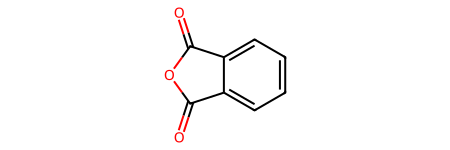

In [46]:
# 無水フタル酸
smiles = "O=C(OC(=O)c1cccc2)c12"
phthalic_anhydride = Chem.MolFromSmiles(smiles)
phthalic_anhydride

 ### Morgan フィンガープリントの取得
RDKitでMorganフィンガープリント（円環フィンガープリント）を取得するには、`rdFingerprintGenerator`モジュールの`GetMorganGenerator`で生成器（ジェネレータ）を作り、その`GetFingerprint`メソッドを呼び出します。半径（デフォルト値は2）とビットベクトルのサイズ（デフォルト値は2048ビット）は`GetMorganGenerator`側の引数として指定します。

下記の例は、無水フタル酸のMorganフィンガープリントを半径2、ビット数512として取得する方法です。


In [47]:
# 半径2、512ビットのMorganフィンガープリント生成器を作成
mfpgen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=512)

# bitInfo（どのビットがどの部分構造に対応するかの記録）を受け取るための入れ物を用意する
ao = rdFingerprintGenerator.AdditionalOutput()
ao.AllocateBitInfoMap()

fp = mfpgen.GetFingerprint(phthalic_anhydride, additionalOutput=ao)
bi = ao.GetBitInfoMap()


《注意》RDKitの旧来の`GetMorganFingerprintAsBitVect`メソッドは非推奨（DEPRECATION WARNING）となっており、代わりに`rdFingerprintGenerator`モジュールの`GetMorganGenerator`（通称MorganGenerator）を使うことが推奨されています。

以前は「新しいMorganGeneratorではbitInfoの取得が煩雑」として旧方式を使っていましたが、`rdFingerprintGenerator.AdditionalOutput`クラスの`AllocateBitInfoMap()`を使えば、旧方式と同じ形式（ビットID→(原子ID, 半径)のタプルのリスト）のbitInfoを簡単に取得できることを確認できたため、本編では**推奨されているMorganGeneratorの方式**で解説します（結果は旧方式と完全に一致します）。


【解説】 **`GetMorganGenerator()`** と **`GetFingerprint()`**

分子からMorganフィンガープリント（0/1のビット列）を作るための、RDKitで推奨されている方法です。`rdkit.Chem.rdFingerprintGenerator`モジュールに含まれています。

```python
from rdkit import Chem
from rdkit.Chem import rdFingerprintGenerator

mol = Chem.MolFromSmiles('CCO')  # SMILES表記から分子を作成

# 1. フィンガープリントの「生成器」を作る（半径・ビット数はここで指定する）
mfpgen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=2048)

# 2. bitInfoを受け取るための入れ物を用意する
ao = rdFingerprintGenerator.AdditionalOutput()
ao.AllocateBitInfoMap()

# 3. フィンガープリントを計算する
fp = mfpgen.GetFingerprint(mol, additionalOutput=ao)
bi = ao.GetBitInfoMap()
```

主なポイント：

- `GetMorganGenerator(radius, fpSize)`：`radius`（部分構造を見る範囲の半径。デフォルトは2）と`fpSize`（ビット列の長さ。デフォルトは2048）を指定して、フィンガープリント生成器を作ります。生成器は同じ設定で複数の分子に繰り返し使えます
- `AdditionalOutput()`：ビットベクトル本体以外の付加情報（今回はbitInfo）を受け取るための入れ物です。`AllocateBitInfoMap()`を呼んでおくことで、どのビットがどの部分構造（原子ID・半径）に対応するかを記録できるようになります
- `mfpgen.GetFingerprint(mol, additionalOutput=ao)`：実際にフィンガープリントを計算します。`ao`を渡しておくと、計算と同時にbitInfoも記録されます
- `ao.GetBitInfoMap()`：記録されたbitInfoを、旧来の`GetMorganFingerprintAsBitVect`の`bitInfo`引数と同じ形式（`{ビットID: ((原子ID, 半径), ...), ...}`）の辞書として取り出します

戻り値の`fp`は0と1が並んだビットベクトルです。1になっているビットは「そのビットに対応する部分構造が分子内に存在する」ことを意味します。


### ビットベクトルのオンビットの確認
オンビット（1となったビット部位）は`GetOnBits()`メソッドより得ることができます。無水フタル酸のオンビットの数は512ビットのうち14ビットのみであることがわかります。

In [48]:
on_bits = list(fp.GetOnBits())
on_bits

[24, 64, 138, 144, 175, 214, 274, 314, 337, 352, 356, 439, 472, 480]

【解説】 **`GetOnBits()`** メソッドについて

フィンガープリントのビットベクトルのうち、1になっている（オンになっている）ビットの番号だけを取り出すメソッドです。`GetMorganGenerator`で作ったフィンガープリントでも、従来と同じように使えます。

```python
from rdkit import Chem
from rdkit.Chem import rdFingerprintGenerator

mol = Chem.MolFromSmiles('CCO')
mfpgen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=2048)
fp = mfpgen.GetFingerprint(mol)

# セットされているビットのインデックスを取得
on_bits = list(fp.GetOnBits())
print(on_bits)
```

2048ビットのほとんどは0（対応する部分構造が分子内に存在しない）です。`GetOnBits()`を使うと、その中から「実際に分子内に存在した部分構造」に対応するビット番号だけを効率よく取り出せます。


### ビットベクトルの部分構造
biに含まれている部分構造を見てみましょう。次のリストの番号は（ビット番号、(原子ID、半径）、・・・）として出力されます。

In [50]:
list(bi.items())

[(24, ((2, 2),)),
 (64, ((3, 1), (7, 1), (8, 1), (1, 1))),
 (138, ((0, 0), (4, 0))),
 (144, ((2, 0),)),
 (175, ((7, 2), (8, 2))),
 (214, ((6, 1), (9, 1))),
 (274, ((2, 1),)),
 (314, ((0, 1), (4, 1))),
 (337, ((6, 0), (7, 0), (8, 0), (9, 0))),
 (352, ((5, 1), (10, 1))),
 (356, ((1, 0), (3, 0), (5, 0), (10, 0))),
 (439, ((3, 2), (1, 2))),
 (472, ((6, 2), (9, 2))),
 (480, ((5, 2), (10, 2)))]

無水フタル酸のビットの出力の原子IDについては、次のように配置されているようです。
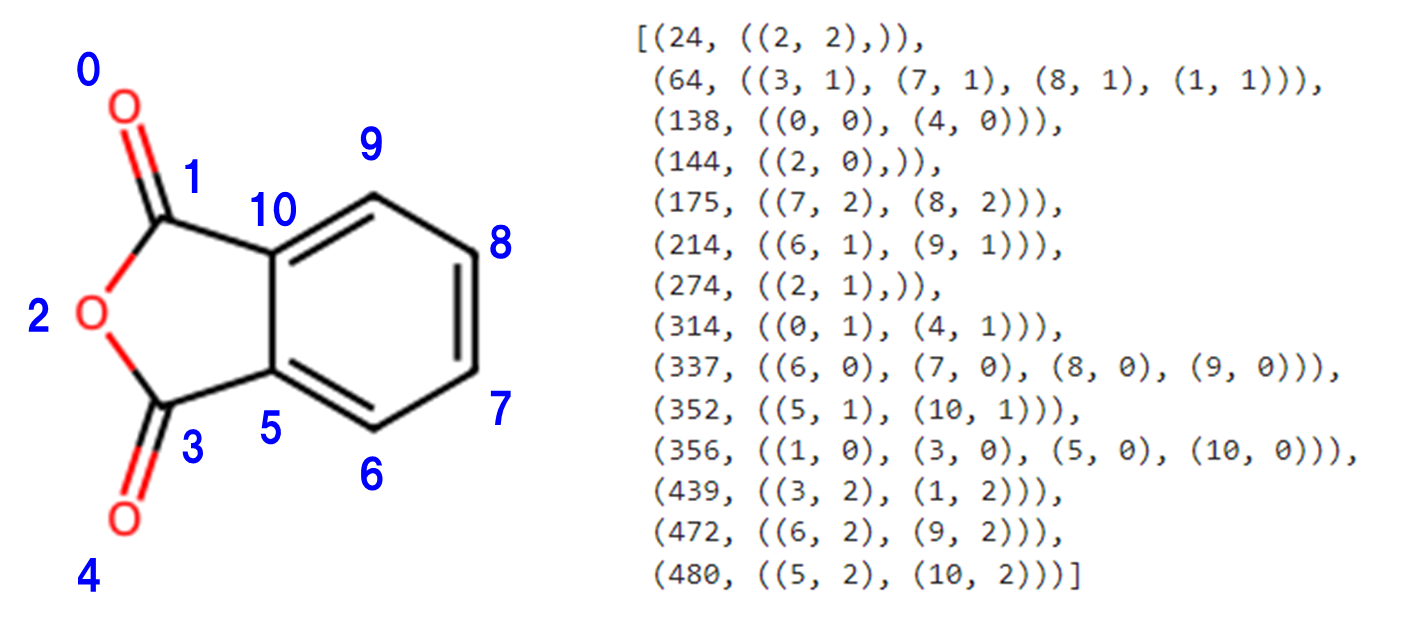

### Morganフィンガープリントを色付表示

上記のリスト表示では、直観的にどの部分構造が何を表しているかを理解することが難しいですが、Drawモジュールの`DrawMorganBit`メソッドを使うと、ビットに対応する部分構造を分子構造図の上に可視化できます。

次の例は、`(24, ((2, 2),))`と表記されるビット（無水フタル酸のbit ID = 24）を描画したものです。原子ID = 2（エーテル酸素）を中心とした半径2の範囲の部分構造がハイライト表示されます。


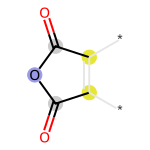

In [51]:
#底本の図1.6(a)相当
from rdkit.Chem import Draw

Draw.DrawMorganBit(phthalic_anhydride, 24, bi)

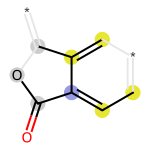

In [52]:
# 最後の480ビット目のビット情報
Draw.DrawMorganBit(phthalic_anhydride, 480,bi)

【解説】 **`DrawMorganBit()`** メソッドについて

指定したビットが分子のどの部分構造に対応するかを、実際の分子構造図の上にハイライト表示するための関数です。数字の羅列だけでは分かりにくいビット情報を、目で見て理解できるようにします。

```python
from rdkit.Chem import Draw
Draw.DrawMorganBit(mol, bitId, bitInfo, **kwargs)
```

主な引数：

- `mol`：対象の分子（`Mol`オブジェクト）
- `bitId`：表示したいビットの番号
- `bitInfo`：`ao.GetBitInfoMap()`（あるいは旧方式の`GetMorganFingerprintAsBitVect`の`bitInfo`引数）から得られる、ビットと部分構造の対応辞書

図中では、青紫色の丸印がその部分構造の中心原子、黄色の丸印が芳香環に含まれる原子、灰色の丸印が芳香環に含まれない（脂肪族の）原子を示しています。


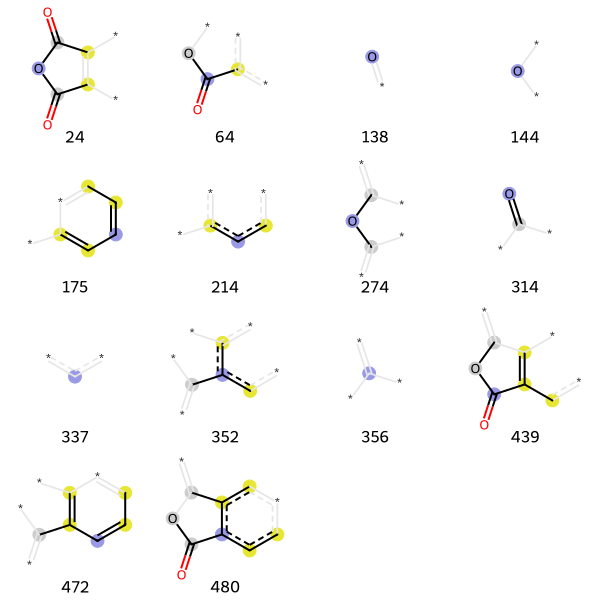

In [53]:
tpls = [(phthalic_anhydride,x,bi) for x in fp.GetOnBits()]

Draw.DrawMorganBits(tpls,
                    molsPerRow=4,
                    legends=[str(x) for x in fp.GetOnBits()]
                   )

### 部分構造の探し方
bitInfoに格納されている原子ID、半径から部分構造の環境を見つけるには`FindAtomEnvironmentOfRadiusN`メソッドを使って探すことができます。

In [54]:
# 原子ID、半径の指定
atom_id, radius = bi[24][0]
atom_id, radius

(2, 2)

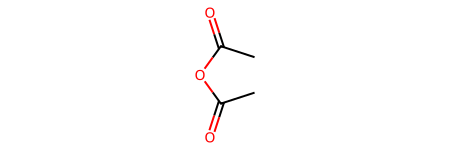

In [55]:
path_ids = Chem.FindAtomEnvironmentOfRadiusN(phthalic_anhydride, 
                                             radius, 
                                             atom_id
                                            )

substructure = Chem.PathToSubmol(phthalic_anhydride, 
                                 path_ids
                                )
substructure

【解説】 **`FindAtomEnvironmentOfRadiusN()`** メソッドについて

「原子ID○番を中心に、半径△の範囲にどんな結合が含まれるか」を調べるためのメソッドです。`bitInfo`に記録された（原子ID、半径）の組から、実際の部分構造を復元したいときに使います。

```python
rdkit.Chem.FindAtomEnvironmentOfRadiusN(mol, radius, atomId, bondedOnly=True)
```

主な引数：

- `mol`：対象の分子（`Mol`オブジェクト）
- `radius`：中心原子から何結合分の範囲まで含めるか
- `atomId`：中心となる原子のインデックス
- `bondedOnly`：Trueの場合、指定範囲内で結合によってつながっている原子のみを対象とします

《注意》戻り値は指定範囲に含まれる**結合（ボンド）のインデックスのリスト**です。原子のインデックスではない点に注意してください。次のセルでは、この結合のリスト（`path_ids`）を`Chem.PathToSubmol()`に渡すことで、対応する部分構造を分子として取り出しています。


### Morganフィンガープリントが分子のどこを指しているかを確認する
`GetSubstructMatch()`で部分構造を指定することで分子全体の中での部分構造を表示することができます。

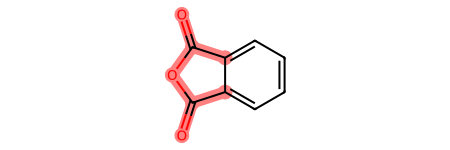

In [56]:
phthalic_anhydride.GetSubstructMatch(substructure)
phthalic_anhydride

【解説】 **`GetSubstructMatch()`** メソッド

与えられた部分構造（サブストラクチャ）が、対象の分子内のどこに存在するかを調べるためのメソッドです。

```python
from rdkit import Chem

# ターゲット分子とサブストラクチャを生成
target_molecule = Chem.MolFromSmiles('CCOCCNC')
substructure = Chem.MolFromSmiles('CCO')

# ターゲット分子内でサブストラクチャが存在するかを検索
matches = target_molecule.GetSubstructMatch(substructure)

if matches:
    print("サブストラクチャが見つかりました。")
    print("マッチの位置: ", matches)
else:
    print("サブストラクチャは見つかりませんでした。")
```

この例では、`CCOCCNC`というSMILES表記のターゲット分子の中に、`CCO`という部分構造が含まれているかを検索しています。

見つかった場合、戻り値はターゲット分子内の対応する原子インデックスが並んだタプルです（サブストラクチャの各原子が、ターゲット分子のどの原子に対応するかを表します）。見つからなかった場合は空のタプルが返ります。


## 2.　RDKitフィンガープリント(Daylightフィンガープリント) (底本P.19)

RDKitフィンガープリントのアルゴリズムは、ケモインフォマティクスで古典的に使われてきたDaylightフィンガープリントの生成手法を踏襲しています。

このアルゴリズムは、分子グラフ内を探索して特定の長さ（デフォルトでは1〜7結合分）のトポロジカルパス（結合のつながりの経路）をすべて洗い出し、それぞれのパスに対してハッシュ関数を適用して固有の数値を生成します。その数値に対応する位置のビットを立てる（1 にする）ことで、分子の特徴を記録します。

すべてのパスを同定したあと、生成された長いビット列は、ユーザーが指定した固定長（デフォルトは2048ビット）または特定のビット密度（オンになっているビットの割合）に収まるまで、ビット列を半分に折るような畳み込み（Folding）処理が行われます。

https://rdkit.org/docs_jp/Getting_Started_with_RDKit_in_Python_jp.html

### RDKitフィンガープリントの呼び込み 
RDKitの`rdkit.Chem`モジュールに含まれている`RDKFingerprint`メソッドは、RDKitフィンガープリントを取得するためのメソッドです。

In [57]:
rdkbi = {}
rdkfp = Chem.RDKFingerprint(phthalic_anhydride, 
                            maxPath=2, 
                            bitInfo=rdkbi
                           )

【解説】 **`Chem.RDKFingerprint()`** 関数について

RDKitフィンガープリント（RDKFingerprint）は、分子の特徴を取り込んだビット列であり、化学的な類似性の評価や機械学習モデルの入力として広く使用されています。`Chem.RDKFingerprint`は、指定した分子のRDKitフィンガープリントを計算するために使用します。

```python
rdkit.Chem.RDKFingerprint(mol, minPath=1, maxPath=7, fpSize=2048, useHs=True)
```

主な引数：

- `mol`：フィンガープリントを計算したい対象の分子（`Mol`オブジェクト）
- `minPath`／`maxPath`：フィンガープリントに含める結合パスの最小・最大長（デフォルトは1〜7）
- `fpSize`：生成されるフィンガープリントのビット数（デフォルトは2048）
- `useHs`：Trueの場合、水素原子も含めてパスを計算します

このほかにも細かい設定を変更する引数が用意されていますが、通常の利用ではデフォルト値のままで問題ありません。より詳しい引数の一覧はRDKit公式ドキュメントを参照してください。


### ビットベクトルの部分構造
このコードでは、与えられたSMILES表記の分子に対してRDKFingerprint（フィンガープリント）を計算し、そのビット列を表示しています。

In [58]:
list(rdkfp.GetOnBits())

[70,
 277,
 294,
 330,
 562,
 744,
 766,
 842,
 929,
 930,
 1026,
 1049,
 1060,
 1075,
 1339,
 1363,
 1907,
 1909,
 1941,
 1960]

In [59]:
from pprint import pprint 
pprint(list(rdkbi.items()))

[(70, [[0, 9], [3, 4]]),
 (277, [[1, 9], [2, 4]]),
 (294, [[5, 6], [5, 10], [6, 7], [7, 8], [8, 11], [10, 11]]),
 (330, [[5, 6], [5, 10], [6, 7], [7, 8], [8, 11], [10, 11]]),
 (562, [[1], [2]]),
 (744, [[4, 10], [4, 5], [9, 11], [9, 10]]),
 (766, [[0, 1], [2, 3]]),
 (842, [[5], [6], [7], [8], [10], [11]]),
 (929, [[0, 1], [2, 3]]),
 (930, [[4], [9]]),
 (1026, [[5], [6], [7], [8], [10], [11]]),
 (1049, [[0, 9], [3, 4]]),
 (1060, [[4], [9]]),
 (1075, [[0], [3]]),
 (1339, [[1], [2]]),
 (1363, [[1, 9], [2, 4]]),
 (1907, [[0], [3]]),
 (1909, [[4, 10], [4, 5], [9, 11], [9, 10]]),
 (1941, [[1, 2]]),
 (1960, [[1, 2]])]


### RDKitフィンガープリントの可視化
フィンガープリントは数字列のみでは理解が及びません。RDKitの`Draw.DrawRDKitBit()`メソッドを使うことで部分構造を可視化し、フィンガープリントを解析することができます。また、特定のビットの分子における存在を直感的に理解ができるようになります。なお、黄色の丸印は芳香環の原子を示しています。

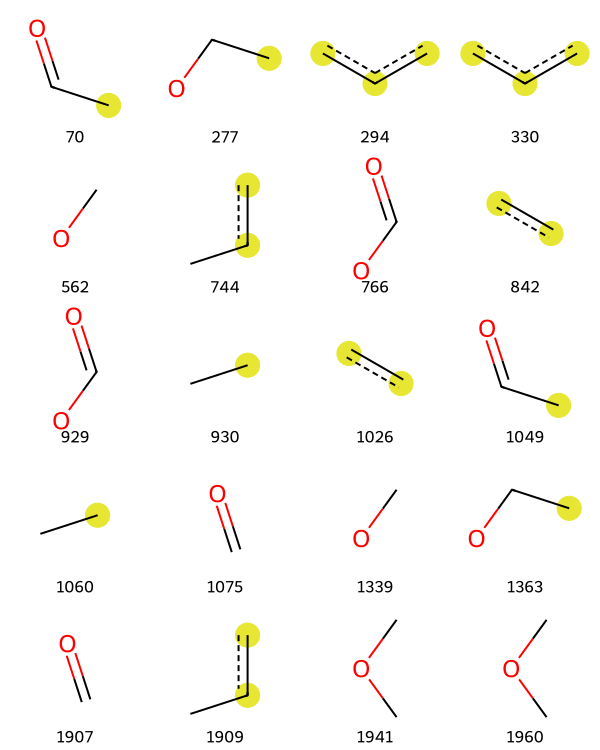

In [60]:
tpls = [(phthalic_anhydride,x,rdkbi) for x in rdkbi]

Draw.DrawRDKitBits(tpls,
                   molsPerRow=4,
                   legends=[str(x) for x in rdkbi]
                  )

【解説】 **`Draw.DrawRDKitBit()`** メソッドについて

フィンガープリントの特定のビットが、分子のどの部分構造に対応するかをグラフィカルに表示するためのメソッドです。

```python
from rdkit.Chem import Draw

img = Draw.DrawRDKitBit(fingerprint, bitId, **kwargs)
```

主な引数：

- `fingerprint`：対象のRDKitフィンガープリント（`ExplicitBitVect`など）
- `bitId`：表示したいビットの番号
- `**kwargs`：`legend`（凡例）など、描画に関する追加オプション

以下は簡単な使用例です。

```python
from rdkit import Chem
from rdkit.Chem import Draw, rdFingerprintGenerator

mol = Chem.MolFromSmiles('CCO')
mfpgen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=1024)
fingerprint = mfpgen.GetFingerprint(mol)

img = Draw.DrawRDKitBit(fingerprint, bitId=100)
img.show()
```

`CCO`（エタノール）のMorganフィンガープリントを計算し、ビット100に対応する部分構造を可視化する例です。


## 3.RDKit記述子(底本 P.11)

RDKitの`Descriptors`モジュールは、分子の物理的・化学的・トポロジカルな性質を数値で表現するための関数を数百種類提供しています。代表的なものを分類すると、次のようになります（`descList`に含まれる217種類のうち、代表的な項目を例示しています。カテゴリ分けは便宜的なものです）。

1. **物理化学的性質**：
   - `MolLogP`：Crippenの原子寄与法による計算LogP（オクタノール／水分配係数の推算値）。分子の疎水性の指標。
   - `TPSA`：Ertl (2000)の位相的極性表面積。分子の極性を表す指標（2次元の結合情報のみから計算されます）。
   - `MolMR`：Crippenのモル屈折率。分子の分極率・サイズに関連する指標。

2. **構造・組成に関する記述子**：
   - `MolWt`：分子量。
   - `HeavyAtomCount`：水素以外の原子数。
   - `RingCount`／`NumAromaticRings`：環の数／芳香環の数。
   - `NumHDonors`／`NumHAcceptors`：水素結合ドナー／アクセプターの数。
   - `NumRotatableBonds`：回転可能な結合の数。
   - `FractionCSP3`：sp3炭素の割合。

3. **トポロジカル指標（グラフ理論に基づく分岐・連結性の指標）**：
   - `BalabanJ`、`Chi0`〜`Chi4`（連結性指数）、`Kappa1`〜`Kappa3`（形状指数）など。分子を原子と結合からなるグラフとみなし、その分岐の仕方や複雑さを数値化したものです。

4. **VSA系記述子（表面積寄与記述子）**：
   - `PEOE_VSA*`、`SlogP_VSA*`、`SMR_VSA*`、`EState_VSA*`など、合計57種類。各原子が分子表面積に寄与する割合を、電荷・LogP・モル屈折率・E-stateなどの性質の値ごとに区分して集計した記述子群です。

これらに加えて、特定の官能基の出現回数を数える`fr_`接頭辞の記述子群（フラグメントカウント系）があります。こちらは後の【参考】節で扱います。


### RDKitフィンガープリントとRDKit記述子の違い
RDKitフィンガープリントとRDKit記述子は異なる概念です。両者は共通点もありますが、目的や計算方法、得られる情報などに以下の違いがあります。

* **RDKit fingerprint（フィンガープリント）**:
   - RDKit fingerprintは、分子の構造に基づいて生成されるバイナリのビット列です。
   - 化学的特徴を取り込んだコンパクトな表現であり、主に分子の類似性評価や機械学習モデルの特徴量として使用されます。
   - 分子の特定の部分構造の存在を表すビットが立っていることで、その分子がその部分構造を持つかどうかを示します。

* **RDKit descriptor（ディスクリプタ）**:
   - RDKit descriptorは、分子の特定の性質や特徴を数値として表す量です。
   - 分子の物理的、化学的、トポロジカルな性質などが計算されます。
   - 主に分子の特性を定量的に理解したり、機械学習モデルの特徴量として使用されたりします。
   - 分子量、水素結合ドナーおよびアクセプターの数、計算LogP、TPSA（極性表面積）などが含まれます。これらはいずれも分子構造から計算される値であり、実験で測定される融点・沸点などの物性値（目的変数として扱われるもの）とは区別されることに注意してください。


RDKit fingerprintは分子の特定の部分構造の存在を示すバイナリ表現であり、主に化学的類似性の評価に使用されます。一方、RDKit descriptorは分子の物理的、化学的、およびトポロジカルな性質を定量化した数値であり、主に分子の特性の解析や機械学習モデルの特徴量として使用されます。どちらもRDKitライブラリの重要な機能であり、分子の解析や予測に幅広く利用されています。

### モジュールインポート  
RDKit記述子は`rdkit.Chem.Descriptors`モジュールから読み出せます。その中にある`descList`メソッドは、RDKit記述子のリストを含んでおり、分子量やフラグメントなどの数百項目の記述子情報を提供します（件数はRDKitのバージョンに依存するため、次のセルで実際に数えます）。

In [61]:
from rdkit.Chem import Descriptors
len(Descriptors.descList)

217

### 記述子の種類

In [62]:
names = list(dict(Descriptors.descList).keys())
names

['MaxAbsEStateIndex',
 'MaxEStateIndex',
 'MinAbsEStateIndex',
 'MinEStateIndex',
 'qed',
 'SPS',
 'MolWt',
 'HeavyAtomMolWt',
 'ExactMolWt',
 'NumValenceElectrons',
 'NumRadicalElectrons',
 'MaxPartialCharge',
 'MinPartialCharge',
 'MaxAbsPartialCharge',
 'MinAbsPartialCharge',
 'FpDensityMorgan1',
 'FpDensityMorgan2',
 'FpDensityMorgan3',
 'BCUT2D_MWHI',
 'BCUT2D_MWLOW',
 'BCUT2D_CHGHI',
 'BCUT2D_CHGLO',
 'BCUT2D_LOGPHI',
 'BCUT2D_LOGPLOW',
 'BCUT2D_MRHI',
 'BCUT2D_MRLOW',
 'AvgIpc',
 'BalabanJ',
 'BertzCT',
 'Chi0',
 'Chi0n',
 'Chi0v',
 'Chi1',
 'Chi1n',
 'Chi1v',
 'Chi2n',
 'Chi2v',
 'Chi3n',
 'Chi3v',
 'Chi4n',
 'Chi4v',
 'HallKierAlpha',
 'Ipc',
 'Kappa1',
 'Kappa2',
 'Kappa3',
 'LabuteASA',
 'PEOE_VSA1',
 'PEOE_VSA10',
 'PEOE_VSA11',
 'PEOE_VSA12',
 'PEOE_VSA13',
 'PEOE_VSA14',
 'PEOE_VSA2',
 'PEOE_VSA3',
 'PEOE_VSA4',
 'PEOE_VSA5',
 'PEOE_VSA6',
 'PEOE_VSA7',
 'PEOE_VSA8',
 'PEOE_VSA9',
 'SMR_VSA1',
 'SMR_VSA10',
 'SMR_VSA2',
 'SMR_VSA3',
 'SMR_VSA4',
 'SMR_VSA5',
 'SMR_VSA6',


### 化学情報の読み込み

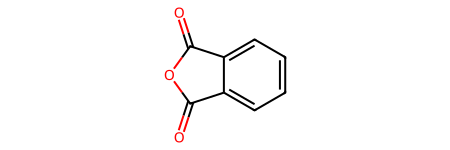

In [63]:
smiles = "O=C(OC(=O)c1cccc2)c12"

phthalic_anhydride = Chem.MolFromSmiles(smiles)
phthalic_anhydride

### 値（value）の呼び出し
descListにある項目はpythonのメソッドとなっています。引数としてmolオブジェクトを加えることで記述子のvalueが返されます。次の３つ例は分子量、TPSA、回転可能な結合数を読み出しています。

In [64]:
#分子量の読み出し
mol_weight = Descriptors.MolWt(phthalic_anhydride)
print("Molecular weight:", mol_weight)

Molecular weight: 148.11699999999996


In [65]:
tpsa = Descriptors.TPSA(phthalic_anhydride)
num_rotatable_bonds = Descriptors.NumRotatableBonds(phthalic_anhydride)


print("TPSA:", tpsa)
print("Number of rotatable bonds:", num_rotatable_bonds)

TPSA: 43.370000000000005
Number of rotatable bonds: 0


### 全記述子の値の呼び出し

In [66]:
def getMolDescriptors(mol, missingVal=None):
    ''' calculate the full list of descriptors for a molecule
    
        missingVal is used if the descriptor cannot be calculated
    '''
    res = {}
    for nm,fn in Descriptors._descList:
        # some of the descriptor fucntions can throw errors if they fail, catch those here:
        try:
            val = fn(mol)
        except:
            # print the error message:
            import traceback
            traceback.print_exc()
            # and set the descriptor value to whatever missingVal is
            val = missingVal
        res[nm] = val
    return res

In [67]:
getMolDescriptors(phthalic_anhydride)

{'MaxAbsEStateIndex': np.float64(10.83287037037037),
 'MaxEStateIndex': np.float64(10.83287037037037),
 'MinAbsEStateIndex': np.float64(0.3587962962962967),
 'MinEStateIndex': np.float64(-0.5503703703703706),
 'qed': 0.4068213457379227,
 'SPS': 14.545454545454545,
 'MolWt': 148.11699999999996,
 'HeavyAtomMolWt': 144.08499999999998,
 'ExactMolWt': 148.01604398799998,
 'NumValenceElectrons': 54,
 'NumRadicalElectrons': 0,
 'MaxPartialCharge': 0.34640400416765926,
 'MinPartialCharge': -0.385656968792507,
 'MaxAbsPartialCharge': 0.385656968792507,
 'MinAbsPartialCharge': 0.34640400416765926,
 'FpDensityMorgan1': 0.9090909090909091,
 'FpDensityMorgan2': 1.3636363636363635,
 'FpDensityMorgan3': 1.8181818181818181,
 'BCUT2D_MWHI': 16.583527533622934,
 'BCUT2D_MWLOW': 10.119205015064276,
 'BCUT2D_CHGHI': 2.277168330707175,
 'BCUT2D_CHGLO': -1.8572692351146736,
 'BCUT2D_LOGPHI': 2.1773371743423433,
 'BCUT2D_LOGPLOW': -1.963070774960751,
 'BCUT2D_MRHI': 6.140682042811686,
 'BCUT2D_MRLOW': 0.0443

## 4. 探索的データ解析　（P.11）
ここでは「data/dataset」フォルダーにあるdelaney-processed.csvをpandasの`read_csv()`からデータフレーム（DataFrame）オブジェクトとして変数dfに格納します。dfは1128化合物に対して10の特徴量からなるデータ行列となっていることが確かめられます。このデータセットの出典・詳細は3_Solubility.ipynbで解説します。

In [23]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt

In [24]:
df = pd.read_csv('./data/dataset/delaney-processed.csv')
df['mol']=df['smiles'].apply(Chem.MolFromSmiles)
df

,Compound ID,ESOL predicted log solubility in mols per litre,Minimum Degree,Molecular Weight,Number of H-Bond Donors,Number of Rings,Number of Rotatable Bonds,Polar Surface Area,measured log solubility in mols per litre,smiles,mol
0,Amigdalin,-0.974,1,457.432,7,3,7,202.32,-0.770,OCC3OC(OCC2OC(OC(C#N)c1ccccc1)C(O)C(O)C2O)C(O)...,<rdkit.Chem.rdchem.Mol object at 0x757789f5e6c0>
1,Fenfuram,-2.885,1,201.225,1,2,2,42.24,-3.300,Cc1occc1C(=O)Nc2ccccc2,<rdkit.Chem.rdchem.Mol object at 0x757789f5e7a0>
2,citral,-2.579,1,152.237,0,0,4,17.07,-2.060,CC(C)=CCCC(C)=CC(=O),<rdkit.Chem.rdchem.Mol object at 0x757789f5e810>
3,Picene,-6.618,2,278.354,0,5,0,0.00,-7.870,c1ccc2c(c1)ccc3c2ccc4c5ccccc5ccc43,<rdkit.Chem.rdchem.Mol object at 0x757789f5e880>
4,Thiophene,-2.232,2,84.143,0,1,0,0.00,-1.330,c1ccsc1,<rdkit.Chem.rdchem.Mol object at 0x757789f5e8f0>
...,...,...,...,...,...,...,...,...,...,...,...
1123,halothane,-2.608,1,197.381,0,0,0,0.00,-1.710,FC(F)(F)C(Cl)Br,<rdkit.Chem.rdchem.Mol object at 0x757789f39700>
1124,Oxamyl,-0.908,1,219.266,1,0,1,71.00,0.106,CNC(=O)ON=C(SC)C(=O)N(C)C,<rdkit.Chem.rdchem.Mol object at 0x757789f39770>
1125,Thiometon,-3.323,1,246.359,0,0,7,18.46,-3.091,CCSCCSP(=S)(OC)OC,<rdkit.Chem.rdchem.Mol object at 0x757789f397e0>
1126,2-Methylbutane,-2.245,1,72.151,0,0,1,0.00,-3.180,CCC(C)C,<rdkit.Chem.rdchem.Mol object at 0x757789f39850>


### RDKit記述子
RDKit記述子の`descList`メソッドより、分子量やフラグメントなどの記述子についてみてみることにしましょう（件数は上のセルで確認した通りです）。

In [25]:
from rdkit.Chem.Descriptors import descList

In [26]:
# 化合物IDの最初のアミグダリンについての記述子とその値
mol = df['mol'][0]

for descriptor in descList:
    value = descriptor[1](mol)
    print(descriptor[0], value)

MaxAbsEStateIndex 10.253328884035504
MaxEStateIndex 10.253328884035504
MinAbsEStateIndex 0.48660209297610146
MinEStateIndex -1.7016049382716056
qed 0.21751778620947723
SPS 41.0625
MolWt 457.4320000000001
HeavyAtomMolWt 430.21600000000024
ExactMolWt 457.1584106839999
NumValenceElectrons 178
NumRadicalElectrons 0
MaxPartialCharge 0.1882658561787514
MinPartialCharge -0.3935665150995826
MaxAbsPartialCharge 0.3935665150995826
MinAbsPartialCharge 0.1882658561787514
FpDensityMorgan1 0.8125
FpDensityMorgan2 1.375
FpDensityMorgan3 1.96875
BCUT2D_MWHI 16.732837958750792
BCUT2D_MWLOW 9.98056032659302
BCUT2D_CHGHI 2.4752382296424598
BCUT2D_CHGLO -2.4250918642238557
BCUT2D_LOGPHI 2.2849354505284443
BCUT2D_LOGPLOW -2.6139256091056042
BCUT2D_MRHI 5.2166929007512515
BCUT2D_MRLOW -0.33372920506026804
AvgIpc 2.81312867812016
BalabanJ 1.6549374848621088
BertzCT 759.6629378441625
Chi0 23.413484604514085
Chi0n 16.862519795262227
Chi0v 16.862519795262227
Chi1 15.277294663077214
Chi1n 9.998815978920186
Chi1v

### 1128化合物の記述子の計算
辞書型の`values()`関数を使ってキーに格納されている値をdescValues変数（オブジェクト）に配置します。

In [68]:
# ディスクリプタ（記述子）の値についてのオブジェクト
descValues = dict(descList).values()

In [69]:
# 結果を格納するリストを初期化する
fng_val = []

# ラムダ関数を定義する
lambda_func = lambda f: f(m)

# リストの各要素に対して処理を行う
for m in df['mol']:
    #  DataFrameの列'mol'の各要素に対して繰り返す
    #  ラムダ関数を適用し、結果をリストに追加する
    result = list(map(lambda_func, descValues))
    fng_val.append(result)

In [70]:
# 1128化合物×記述子数のarray
#fng_val

辞書型の`key()`関数を使ってキー名（メタデータ）をnames変数（オブジェクト）に配置します。これは、次のデータフレーム形式で表示するときの列ラベルに使います。

In [71]:
# ディスクリプタ（記述子）の一覧 209個の内容
descNames = list(dict(descList).keys())

In [72]:
# 1128化合物×記述子数のpandasのdataframe変換
df_rdkit = pd.DataFrame(fng_val, columns=descNames)
df_rdkit

,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,HeavyAtomMolWt,ExactMolWt,NumValenceElectrons,...,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
0,10.253329,10.253329,0.486602,-1.701605,0.217518,41.062500,457.432,430.216,457.158411,178,...,0,0,0,0,0,0,0,0,0,0
1,11.724911,11.724911,0.145880,-0.145880,0.811283,9.933333,201.225,190.137,201.078979,76,...,0,0,0,0,0,0,0,0,0,0
2,10.020498,10.020498,0.845090,0.845090,0.343706,11.000000,152.237,136.109,152.120115,62,...,0,0,0,0,0,0,0,0,0,0
3,2.270278,2.270278,1.301055,1.301055,0.291526,11.636364,278.354,264.242,278.109550,102,...,0,0,0,0,0,0,0,0,0,0
4,2.041667,2.041667,1.712963,1.712963,0.448927,8.000000,84.143,80.111,84.003371,26,...,0,0,0,0,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1123,10.999421,10.999421,1.916667,-4.317901,0.523506,16.714286,197.381,196.373,195.890224,44,...,0,0,0,0,0,0,0,0,0,0
1124,11.337508,11.337508,0.123704,-0.705457,0.293876,10.714286,219.266,206.162,219.067762,80,...,1,0,0,0,0,0,0,0,0,0
1125,5.174287,5.174287,1.011373,-1.984662,0.506070,11.916667,246.359,231.239,245.997179,74,...,1,0,0,0,0,0,0,0,0,0
1126,2.222222,2.222222,0.884259,0.884259,0.444441,9.600000,72.151,60.055,72.093900,32,...,0,0,0,0,0,0,0,0,0,0


このようにSMILES情報があればRDKitでmolオブジェクト化させ、機械学習で必要となる特徴量を記述子から簡単に生成することができます。

### 記述子のEDA
底本の【1.2 数値データ可視化　探索的データ解析】にあるコードを使って記述子の可視化を行ってみましょう。ここでは分散が0の記述子は排除し、値が100以下の正値の条件で合致するものの中で10個の記述子の散布図をプロットします。なお、pandasでは分散値は`var()`メソッドで得ることができます。

In [73]:
# 分散値が100以下の正値の条件
is_selected = np.logical_and(df_rdkit.var()>0, df_rdkit.var() <= 100)
count = np.sum(is_selected)
count

np.int64(170)

【解説】 **`np.logical_and()`** メソッド

NumPyの関数で、2つの真偽値（True/False）の配列に対して、要素ごとの論理積（AND）演算を行います。

```python
import numpy as np

arr1 = np.array([True, True, False, False])
arr2 = np.array([True, False, True, False])

result = np.logical_and(arr1, arr2)
print(result)
```

出力:
```
[ True False False False]
```

両方ともTrueの位置だけがTrueになります。複数の条件（例：「分散が0より大きい」かつ「値が100以下」）を同時に満たす要素を絞り込みたいときに便利です。


In [74]:
#　条件（分散>0かつ100以下）を満たす記述子の中から、先頭10個を可視化対象として選ぶ。
# 注意：is_selected自体は全記述子に対する真偽値のSeriesなので、条件を満たすものだけに
# 絞り込んでから先頭10個を取り出す（絞り込まずに先頭10個を取ると条件を満たさない記述子が混入する）。
selected_descriptors = is_selected[is_selected].keys().tolist()[:10]
selected_descriptors

['MaxAbsEStateIndex',
 'MaxEStateIndex',
 'MinAbsEStateIndex',
 'MinEStateIndex',
 'qed',
 'MaxPartialCharge',
 'MinPartialCharge',
 'MaxAbsPartialCharge',
 'MinAbsPartialCharge',
 'FpDensityMorgan1']

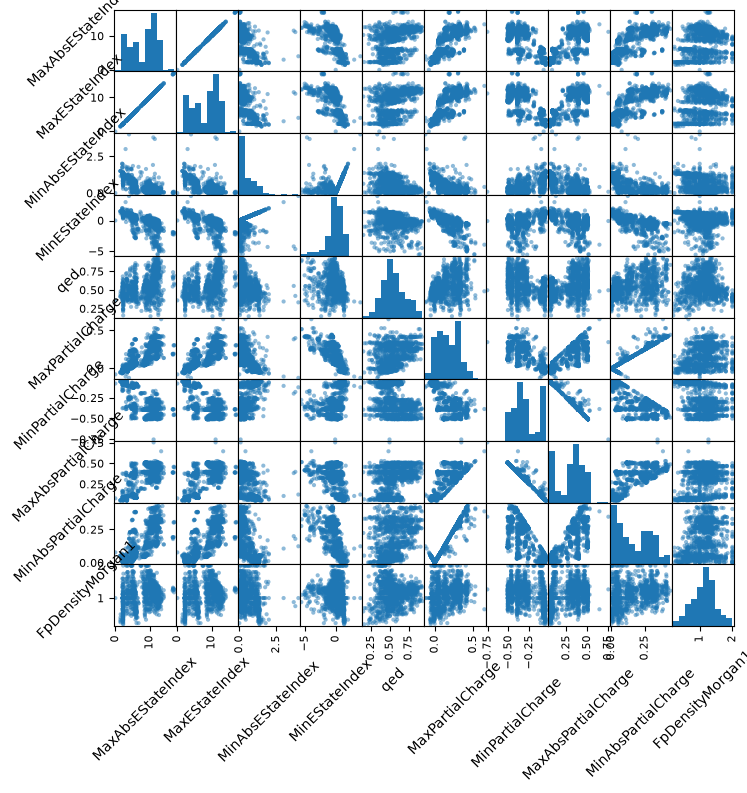

In [75]:
# 図2：選択した記述子の散布図行列（底本 図1.1(a)相当）
from pandas.plotting import scatter_matrix

sm = scatter_matrix(df_rdkit[selected_descriptors], figsize=(8,8))

[s.xaxis.label.set_rotation(45) for s in sm.reshape(-1)]
[s.yaxis.label.set_rotation(45) for s in sm.reshape(-1)]

plt.show()

<Axes: >

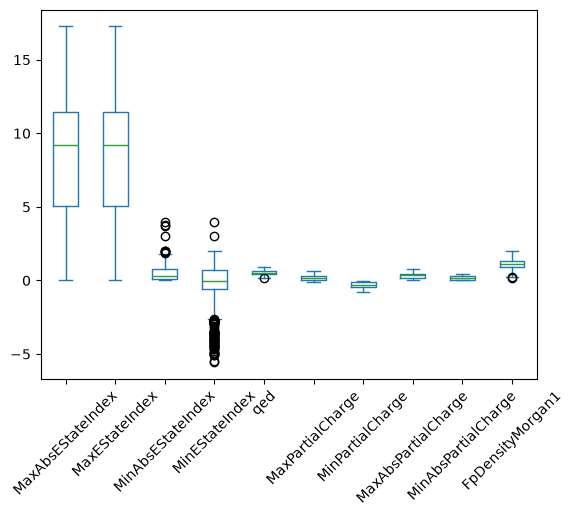

In [76]:
# 図3：選択した記述子の箱ひげ図（底本 図1.1(b)相当）
df_rdkit[selected_descriptors].plot.box(rot=45)

### 【参考】RDKit記述子（フラグメント情報）

descListに含まれている記述子のうち、接頭に`fr_`がつく特徴量は、部分構造（官能基）の出現回数を数えるフラグメントカウント系の記述子です。たとえば`fr_benzene`はベンゼン環の数、`fr_ester`はエステル基の数、というように、特定の官能基が分子中に何個含まれるかを整数値で返します。

具体的な項目名と件数はRDKitのバージョンによって増減するため、ここでは実際のコードで`fr_`から始まる記述子名を抽出して確認します。


In [77]:
# fr_ から始まる記述子名を実際に抽出する（ハンドメイドのリストではなく、コードの実行結果を正とする）
fr_names = [n for n in descNames if n.startswith('fr_')]
print(f'fr_接頭辞を持つ記述子の数: {len(fr_names)}')
fr_names

fr_接頭辞を持つ記述子の数: 85


['fr_Al_COO',
 'fr_Al_OH',
 'fr_Al_OH_noTert',
 'fr_ArN',
 'fr_Ar_COO',
 'fr_Ar_N',
 'fr_Ar_NH',
 'fr_Ar_OH',
 'fr_COO',
 'fr_COO2',
 'fr_C_O',
 'fr_C_O_noCOO',
 'fr_C_S',
 'fr_HOCCN',
 'fr_Imine',
 'fr_NH0',
 'fr_NH1',
 'fr_NH2',
 'fr_N_O',
 'fr_Ndealkylation1',
 'fr_Ndealkylation2',
 'fr_Nhpyrrole',
 'fr_SH',
 'fr_aldehyde',
 'fr_alkyl_carbamate',
 'fr_alkyl_halide',
 'fr_allylic_oxid',
 'fr_amide',
 'fr_amidine',
 'fr_aniline',
 'fr_aryl_methyl',
 'fr_azide',
 'fr_azo',
 'fr_barbitur',
 'fr_benzene',
 'fr_benzodiazepine',
 'fr_bicyclic',
 'fr_diazo',
 'fr_dihydropyridine',
 'fr_epoxide',
 'fr_ester',
 'fr_ether',
 'fr_furan',
 'fr_guanido',
 'fr_halogen',
 'fr_hdrzine',
 'fr_hdrzone',
 'fr_imidazole',
 'fr_imide',
 'fr_isocyan',
 'fr_isothiocyan',
 'fr_ketone',
 'fr_ketone_Topliss',
 'fr_lactam',
 'fr_lactone',
 'fr_methoxy',
 'fr_morpholine',
 'fr_nitrile',
 'fr_nitro',
 'fr_nitro_arom',
 'fr_nitro_arom_nonortho',
 'fr_nitroso',
 'fr_oxazole',
 'fr_oxime',
 'fr_para_hydroxylation',

In [78]:
# 代表的なfr_記述子の例（意味が明確なものを抜粋。全項目の意味はRDKit公式ドキュメント参照）
# https://www.rdkit.org/docs/source/rdkit.Chem.Fragments.html
fr_examples = {
    'fr_benzene': 'ベンゼン環の数',
    'fr_phenol': 'フェノール基の数',
    'fr_ether': 'エーテル基の数',
    'fr_ester': 'エステル基の数',
    'fr_amide': 'アミド基の数',
    'fr_nitro': 'ニトロ基の数',
    'fr_halogen': 'ハロゲン基の数',
    'fr_COO': 'カルボン酸基の数',
}

for name, meaning in fr_examples.items():
    value = getattr(Descriptors, name)(phthalic_anhydride)
    print(f'{name:20s} {meaning:15s} -> 無水フタル酸での値: {value}')

fr_benzene           ベンゼン環の数         -> 無水フタル酸での値: 1
fr_phenol            フェノール基の数        -> 無水フタル酸での値: 0
fr_ether             エーテル基の数         -> 無水フタル酸での値: 1
fr_ester             エステル基の数         -> 無水フタル酸での値: 2
fr_amide             アミド基の数          -> 無水フタル酸での値: 0
fr_nitro             ニトロ基の数          -> 無水フタル酸での値: 0
fr_halogen           ハロゲン基の数         -> 無水フタル酸での値: 0
fr_COO               カルボン酸基の数        -> 無水フタル酸での値: 0


公式ドキュメントに全項目の一覧と定義があります： https://www.rdkit.org/docs/source/rdkit.Chem.Fragments.html

## まとめ

本編では、RDKitで利用できる3種類の代表的な分子記述子（Morganフィンガープリント、RDKitフィンガープリント、RDKit記述子）を取り上げ、それぞれの計算方法・可視化方法を確認しました。

- **Morganフィンガープリント**・**RDKitフィンガープリント**は、分子構造をビット列（0/1のベクトル）として表現するもので、化学的類似性の評価や機械学習の入力特徴量として利用できます。
- **RDKit記述子**は、分子量・TPSA・水素結合ドナー数など、分子の物理的・化学的性質を数値として表現するものです。1つの分子から数百種類の記述子を一括計算できることを、Delaney水溶解度データセット（1128化合物）を例に確認しました。
- 分散が極端に大きい／0の記述子を除外してから可視化することで、記述子間の関係を見やすくする、という探索的データ解析（EDA）の基本的な考え方も扱いました。

## 本ノートブックで扱っていないこと（今後の課題）

- 記述子・フィンガープリントを実際に機械学習モデル（回帰・分類）の入力として使う手順は扱っていません。3_Solubility.ipynbで、Delaneyデータセットの記述子を使った溶解度予測モデルを構築します。
- Morganフィンガープリント・RDKitフィンガープリントを使った分子間類似性（Tanimoto係数など）の計算は扱っていません。
- Mordred記述子など、RDKit以外の記述子計算ライブラリとの比較は2-2_Fragment_Count.ipynbで一部扱います。

## 演習問題

1. 無水フタル酸以外の任意の分子（例：アスピリン `CC(=O)Oc1ccccc1C(=O)O`）についてMorganフィンガープリント（半径2、512ビット）を計算し、オンビットの数を比較してみましょう。
2. `selected_descriptors`を「分散が0より大きく100以下」ではなく「分散が0より大きく10以下」に条件を変えると、選ばれる記述子はどのように変わるか確認してみましょう。
3. `fr_`記述子のうち、あなたが実験で扱う分子に含まれそうな官能基（例：`fr_ester`、`fr_amide`など）を3つ選び、Delaneyデータセット中の1128化合物についてその値の分布をヒストグラムで可視化してみましょう。
